In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import sklearn

In [2]:
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import f_regression

In [3]:
import statsmodels.api as sm

In [4]:
from vaccination_functions import *
from acs_data_functions import *

In [5]:
tx_mmr_vac_rates = pd.read_csv("../TX_MMR_vax_rate_24_25.csv")
tx_mmr_vac_rates.head()

,Facility Number,School Type,School District or Name,Facility Address,County,MMR Vaccination Rate,Age Group
0,9057829000,Public School,A+ ACADEMY,"8225 BRUTON RD, DALLAS, TX, .",Dallas,96.77,Kindergarten
1,9109901000,Public School,ABBOTT ISD,"P O BOX 226, ABBOTT, TX, .",Hill,95.24,Kindergarten
2,9095901000,Public School,ABERNATHY ISD,"505 7TH ST, ABERNATHY, TX, .",Hale,93.22,Kindergarten
3,9221901000,Public School,ABILENE ISD,"P O BOX 981, ABILENE, TX, .",Taylor,97.76,Kindergarten
4,9014901000,Public School,ACADEMY ISD,"704 E MAIN ST, LITTLE RIVER, TX, .",Bell,98.04,Kindergarten


In [6]:
np.min(tx_mmr_vac_rates['MMR Vaccination Rate'])

np.float64(5.26)

(5.0, 100.0)

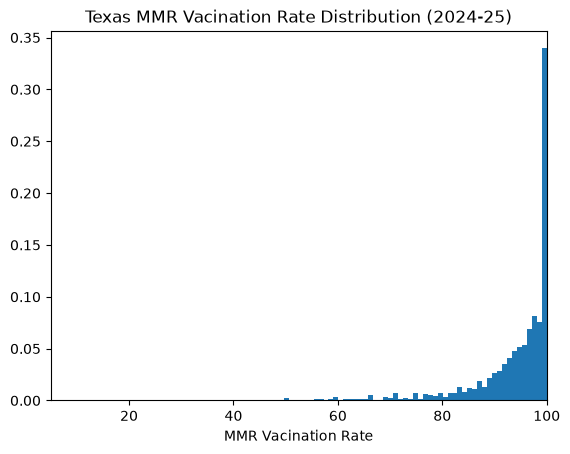

In [7]:
plt.hist(tx_mmr_vac_rates['MMR Vaccination Rate'], bins=100, range=(5, 100), density=True)
plt.xlabel('MMR Vacination Rate')
plt.title('Texas MMR Vacination Rate Distribution (2024-25)')
plt.xlim(5, 100)
#plt.savefig('../plots/tx_mmr_rates_distribution_normalized_24_25.png', bbox_inches="tight")

In [8]:
counties_with_vac = tx_mmr_vac_rates['County'].unique()
#tx_mmr_vac_rates['County'].unique()

In [9]:
acs_data_path = "../acs_data/"

#age_df = pd.read_csv(acs_data_path+"tx_county_agePop_24.csv")
#age_var_df = pd.read_csv(acs_data_path+"ageVars_acs.csv")

#race_df = pd.read_csv(acs_data_path+"tx_county_racePop_24.csv")
#race_var_df = pd.read_csv(acs_data_path+"raceVars_acs.csv")

education_df = pd.read_csv(acs_data_path+"tx_county_education_24.csv")
education_var_df = pd.read_csv(acs_data_path+"educationVars_acs.csv")

#enrollment_df = pd.read_csv(acs_data_path+"tx_county_enrollment_24.csv")
#enrollment_var_df = pd.read_csv(acs_data_path+"enrollmentVars_acs.csv")

enrollment_ext_df = pd.read_csv(acs_data_path+"tx_county_enrollment_24_extended.csv")
enrollment_var_ext_df = pd.read_csv(acs_data_path+"enrollmentVars_acs_extended.csv")

#poverty_df = pd.read_csv(acs_data_path+"tx_county_poverty_24.csv")
#poverty_var_df = pd.read_csv(acs_data_path+"povertyVars_acs.csv")


In [10]:
enroll_concepts = ['B14001_', 'B14002_', 'B14003_', 'B14006_', 'B14007', 'B14007_', 'B14007A_', 'B14007B_', 'B14007C_',
                   'B14007D_', 'B14007E_', 'B14007F_', 'B14007G_', 'B14007H_', 'B14007I_',]
enroll_df_dict = {}
for c in enroll_concepts:
    enroll_sub_df = enrollment_ext_df[enrollment_ext_df['variable'].str.contains(c)]
    enroll_df_dict[c] = enroll_sub_df

In [11]:
enroll_totals_df = enroll_df_dict['B14001_']
enroll_gender_grade_df = enroll_df_dict['B14002_']
enroll_gender_type_age_df = enroll_df_dict['B14003_']
enroll_poverty_df = enroll_df_dict['B14006_']
enroll_detailed_grade_race_df = enroll_df_dict['B14007']
enroll_detailed_grade_all_df = enroll_df_dict['B14007_']

In [12]:
edu_concepts = ['B15001_', 'B15003_']
edu_df_dict = {}
for c in edu_concepts:
    edu_sub_df = education_df[education_df['variable'].str.contains(c)]
    edu_df_dict[c] = edu_sub_df

In [13]:
edu_totals_df = edu_df_dict['B15001_']
edu_total_by_level_df = edu_df_dict['B15003_']

In [14]:
education_total_with_var_all, education_total_with_var_no_gender = create_predictor_datasets(edu_totals_df, education_var_df, counties_with_vac)
education_total_level_with_var_all, education_total_level_with_var_no_gender = create_predictor_datasets(edu_total_by_level_df, education_var_df, counties_with_vac)

In [15]:
education_total_with_var_all.columns

Index(['Estimate_Total_Female_18_24_9th_12th_grade,_no_diploma_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Associate's_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Bachelor's_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Graduate_or_professional_degree_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_High_school_graduate_(includes_equivalency)_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Less_than_9th_grade_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Sex_by_Age_by_Educational_Attainment_for_the_Population_18_Years_and_Over',
       'Estimate_Total_Female_18_24_Some_college,_no_deg

In [16]:
#education_total_level_with_var_all.columns
edu_attainment_percent = pd.DataFrame()
for col in education_total_level_with_var_all.drop(columns='Estimate_Total_Educational_Attainment_for_the_Population_25_Years_and_Over').columns:
    edu_attainment_percent['Percent_'+col] = education_total_level_with_var_all[col]/education_total_level_with_var_all['Estimate_Total_Educational_Attainment_for_the_Population_25_Years_and_Over']
edu_attainment_percent.columns = edu_attainment_percent.columns.str.replace({'_Estimate_Total_': '_', '_for_the_Population_':'_'}, regex=True)

In [17]:
edu_attainment_percent.columns

Index(['Percent_10th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_11th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_12th_grade,_no_diploma_Educational_Attainment_25_Years_and_Over',
       'Percent_1st_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_2nd_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_3rd_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_4th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_5th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_6th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_7th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_8th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_9th_grade_Educational_Attainment_25_Years_and_Over',
       'Percent_Associate's_degree_Educational_Attainment_25_Years_and_Over',
       'Percent_Bachelor's_degree_Educational_Attainment_25_Years_and_Over',
  

In [18]:
#age_with_var_all, age_with_var_no_gender = create_predictor_datasets(age_df, age_var_df, counties_with_vac)
#race_with_var_all, race_with_var_no_gender = create_predictor_datasets(race_df, race_var_df, counties_with_vac)
education_with_var_all, education_with_var_no_gender = create_predictor_datasets(education_df, education_var_df, counties_with_vac)
#enrollment_with_var_all, enrollment_with_var_no_gender = create_predictor_datasets(enrollment_df, enrollment_var_df, counties_with_vac)
#enrollment_ext_with_var_all, enrollment_ext_with_var_no_gender = create_predictor_datasets(enrollment_ext_df, enrollment_var_ext_df, counties_with_vac)
#poverty_with_var_all, poverty_with_var_no_gender = create_predictor_datasets(poverty_df, poverty_var_df, counties_with_vac)

In [19]:
enrollment_gender_grade_with_var_all, enrollment_gender_grade_with_var_no_gender = create_predictor_datasets(enroll_gender_grade_df, enrollment_var_ext_df, counties_with_vac)
enrollment_totals_with_var_all, enrollment_totals_with_var_no_gender = create_predictor_datasets(enroll_totals_df, enrollment_var_ext_df, counties_with_vac)
enrollment_gender_type_age_with_var_all, enrollment_gender_type_age_with_var_no_gender = create_predictor_datasets(enroll_gender_type_age_df, enrollment_var_ext_df, counties_with_vac)
enrollment_poverty_with_var_all, enrollment_poverty_with_var_no_gender = create_predictor_datasets(enroll_poverty_df, enrollment_var_ext_df, counties_with_vac)
enrollment_grade_race_with_var_all, enrollment_grade_race_with_var_no_gender = create_predictor_datasets(enroll_detailed_grade_race_df, enrollment_var_ext_df, counties_with_vac)

In [20]:
enrollment_totals_with_var_all.columns = enrollment_totals_with_var_all.columns.str.replace({'_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_grade_with_var_all.columns = enrollment_gender_grade_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Level_of_School_by_Type_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_gender_type_age_with_var_all.columns = enrollment_gender_type_age_with_var_all.columns.str.replace({'_Sex_by_School_Enrollment_by_Type_of_School_by_Age_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_poverty_with_var_all.columns = enrollment_poverty_with_var_all.columns.str.replace({'_in_the_Past_12_Months_by_School_Enrollment_by_Level_of_School_for_the_Population_': '_School_Enrollment_'}, regex=True)
enrollment_grade_race_with_var_all.columns = enrollment_grade_race_with_var_all.columns.str.replace({'_by_Detailed_Level_of_School_for_the_Population_': '_'}, regex=True)

In [21]:
total_enrolled_grade_schoolType = enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_School_Enrollment_3_Years_and_Over'] + enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollment_by_grade_schoolType_percent = pd.DataFrame()

enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_college_undergraduate_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_college_undergraduate_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_college_undergraduate_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_college_undergraduate_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_kindergarten_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_kindergarten_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_kindergarten_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_kindergarten_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Private'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Private_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Private_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType
enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Public'] = (enrollment_gender_grade_with_var_all['Estimate_Total_Female_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Public_school_School_Enrollment_3_Years_and_Over']+enrollment_gender_grade_with_var_all['Estimate_Total_Male_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Public_school_School_Enrollment_3_Years_and_Over'])/total_enrolled_grade_schoolType

enrollment_by_grade_schoolType_percent['Percent_Private'] = enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Private'] + enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Private'] + enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Private'] + enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Private'] + enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Private']
enrollment_by_grade_schoolType_percent['Percent_Public'] = enrollment_by_grade_schoolType_percent['Percent_Undergraduate_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_1_4_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_5_8_Public'] + enrollment_by_grade_schoolType_percent['Percent_grade_9_12_Public'] + enrollment_by_grade_schoolType_percent['Percent_Graduate_Professional_Public'] + enrollment_by_grade_schoolType_percent['Percent_Kindergarten_Public'] + enrollment_by_grade_schoolType_percent['Percent_Nursery_Preschool_Public']

In [22]:
#enrollment_totals_with_var_all.columns

enrollemnt_by_grade_percent = pd.DataFrame()

enrollemnt_by_grade_percent['Percent_Not_Enrolled'] = enrollment_totals_with_var_all['Estimate_Total_Not_enrolled_in_school_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Undergraduate'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_college,_undergraduate_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_1_4'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_1_grade_4_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_5_8'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_5_grade_8_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_grade_9_12'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_grade_9_grade_12_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Kindergarten'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_kindergarten_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Nursery_Preschool'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']
enrollemnt_by_grade_percent['Percent_Enrolled_Graduate_Professional'] = enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_Graduate_or_professional_school_School_Enrollment_3_Years_and_Over']/enrollment_totals_with_var_all['Estimate_Total_Enrolled_in_school_School_Enrollment_3_Years_and_Over']


In [23]:
#enrollment_poverty_with_var_all.columns
enrollment_poverty_percent = pd.DataFrame()

enrollment_poverty_percent['Percent_Above_Poverty_Undergraduate_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_college_undergraduate_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_1_4_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_5_8_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_grade_9_12_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Graduate_Professional_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Kindergarten_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_kindergarten_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Nursery_Preschool_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Above_Poverty_Not_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_at_or_above_the_poverty_level_Not_enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']

enrollment_poverty_percent['Percent_Below_Poverty_Undergraduate_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_college_undergraduate_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_1_4_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_1_grade_4_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_5_8_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_5_grade_8_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_grade_9_12_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_grade_9_grade_12_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Graduate_Professional_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_graduate_or_professional_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Kindergarten_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_kindergarten_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Nursery_Preschool_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Enrolled_in_nursery_school,_preschool_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']
enrollment_poverty_percent['Percent_Below_Poverty_Not_Enrolled_past_12_months'] = enrollment_poverty_with_var_all['Estimate_Total_Income_in_the_past_12_months_below_the_poverty_level_Not_enrolled_in_school_Poverty_Status_School_Enrollment_3_Years_and_Over']/enrollment_poverty_with_var_all['Estimate_Total_Poverty_Status_School_Enrollment_3_Years_and_Over']

In [24]:
enrollment_grade_race_percent = pd.DataFrame()
total_enrolled_grade_race = enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over']
enrollment_grade_race_percent['Percent_School_Enrollment_American_Indian_and_Alaska_Native_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(American_Indian_and_Alaska_Native_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Asian_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Asian_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Black_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Black_or_African_American_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Hispanic_or_Latino'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Hispanic_or_Latino)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Native_Hawaiian_and_Other_Pacific_Islander_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Native_Hawaiian_and_Other_Pacific_Islander_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Some_Other_Race_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Some_Other_Race_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_Two_or_More_Races'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(Two_or_More_Races)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_White_Alone'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(White_Alone)']/total_enrolled_grade_race
enrollment_grade_race_percent['Percent_School_Enrollment_White_Alone_Not_Hispanic_or_Latino'] =  enrollment_grade_race_with_var_all['Estimate_Total_School_Enrollment_3_Years_and_Over_(White_Alone,_Not_Hispanic_or_Latino)']/total_enrolled_grade_race


In [25]:
high_school_df, middle_school_df, elementary_school_df = seperate_level_of_school_enrollment(enrollment_grade_race_with_var_all)

In [26]:
calculate_race_percents_by_school_level_enrollment(high_school_df, enrollment_grade_race_percent, school_level="high")
calculate_race_percents_by_school_level_enrollment(middle_school_df, enrollment_grade_race_percent, school_level="middle")
calculate_race_percents_by_school_level_enrollment(elementary_school_df, enrollment_grade_race_percent, school_level="elementary")

In [27]:
enrollment_percent_df_list = [enrollment_grade_race_percent, enrollment_poverty_percent, enrollemnt_by_grade_percent, enrollment_by_grade_schoolType_percent]
all_enrollment_percent = combine_acs_variables(enrollment_percent_df_list)
all_vac_enrollment_percent = vac_predictor_merge(tx_mmr_vac_rates, all_enrollment_percent)

In [28]:
enroll_edu_percent_df_list = [enrollment_grade_race_percent, enrollment_poverty_percent, enrollemnt_by_grade_percent, enrollment_by_grade_schoolType_percent, edu_attainment_percent]
all_enroll_edu_percent = combine_acs_variables(enroll_edu_percent_df_list)
all_vac_enroll_edu_percent = vac_predictor_merge(tx_mmr_vac_rates, all_enroll_edu_percent)

In [31]:
#ridge_feats = all_vac_enrollment_percent.drop(columns=['County','MMR Vaccination Rate']).columns
coef_list_enroll_ridge, ci_results_df_enroll_ridge = run_bootstrap_get_ci(1000, enroll_ridge_datasets['x_train'], enroll_ridge_datasets['y_train'], feature_names=enroll_ridge_feats, model_type='Ridge')
ci_results_df_enroll_ridge.head()

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
0,Percent_School_Enrollment_American_Indian_and_...,-0.024333,-0.518565,0.464465,Not Signficant
1,Percent_School_Enrollment_Asian_Alone,-1.992805,-4.257670,0.428585,Not Signficant
2,Percent_School_Enrollment_Black_Alone,1.465840,-0.336906,3.299048,Not Signficant
3,Percent_School_Enrollment_Hispanic_or_Latino,-0.315333,-4.571642,3.861527,Not Signficant
4,Percent_School_Enrollment_Native_Hawaiian_and_...,-0.498528,-0.989871,-0.054236,Signficant


In [32]:
ci_results_df_enroll_ridge[ci_results_df_enroll_ridge['Coeff Signficance'] == 'Signficant']

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
4,Percent_School_Enrollment_Native_Hawaiian_and_...,-0.498528,-0.989871,-0.054236,Signficant
5,Percent_School_Enrollment_Some_Other_Race_Alone,1.309253,0.100856,2.580617,Signficant
28,Percent_Elementary_Two_or_More_Races,0.784865,0.093021,1.472308,Signficant
35,Percent_Above_Poverty_grade_5_8_past_12_months,-1.493958,-2.885618,-0.219005,Signficant
38,Percent_Above_Poverty_Kindergarten_past_12_months,1.865965,0.471979,3.398196,Signficant
39,Percent_Above_Poverty_Nursery_Preschool_past_1...,1.764541,0.001830,3.562796,Signficant
44,Percent_Below_Poverty_grade_5_8_past_12_months,-1.629792,-2.865713,-0.431547,Signficant
47,Percent_Below_Poverty_Kindergarten_past_12_months,1.258140,0.294912,2.239184,Signficant
54,Percent_Enrolled_grade_5_8,0.853023,0.107649,1.567762,Signficant
56,Percent_Enrolled_Kindergarten,-0.859032,-1.733689,-0.115960,Signficant


In [35]:
coef_list_enroll_linear, ci_results_df_enroll_linear = run_bootstrap_get_ci(1000, enroll_linear_datasets['x_train'], enroll_linear_datasets['y_train'], feature_names=enroll_linear_feats, model_type='Linear')
ci_results_df_enroll_linear.head()

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
0,Percent_School_Enrollment_American_Indian_and_...,0.180541,-0.329098,0.708255,Not Signficant
1,Percent_School_Enrollment_Asian_Alone,-3.775407,-7.018743,-0.765924,Signficant
2,Percent_School_Enrollment_Black_Alone,-0.201247,-3.629346,3.453278,Not Signficant
3,Percent_School_Enrollment_Hispanic_or_Latino,-4.467495,-14.329212,6.008515,Not Signficant
4,Percent_School_Enrollment_Native_Hawaiian_and_...,-0.753404,-1.285045,-0.216051,Signficant


In [36]:
ci_results_df_enroll_linear[ci_results_df_enroll_linear['Coeff Signficance'] == 'Signficant']

,Predictor,Mean,CI_Lower,CI_Upper,Coeff Signficance
1,Percent_School_Enrollment_Asian_Alone,-3.775407,-7.018743,-0.765924,Signficant
4,Percent_School_Enrollment_Native_Hawaiian_and_...,-0.753404,-1.285045,-0.216051,Signficant
6,Percent_School_Enrollment_Two_or_More_Races,-1.953573,-3.830154,-0.072117,Signficant
10,Percent_High_School_Black_or_African_American_...,-1.676855,-3.017976,-0.336700,Signficant
15,Percent_High_School_Hispanic_or_Latino_Alone,-3.508830,-7.042988,-0.193326,Signficant
16,Percent_High_School_White_Alone_Not_Hispanic_o...,-4.515595,-8.877928,-0.460823,Signficant
28,Percent_Elementary_Two_or_More_Races,1.520680,0.753962,2.332059,Signficant
30,Percent_Elementary_White_Alone,-1.400400,-2.471466,-0.325541,Signficant
38,Percent_Above_Poverty_Kindergarten_past_12_months,2.033076,0.720145,3.483717,Signficant
47,Percent_Below_Poverty_Kindergarten_past_12_months,1.202336,0.319996,2.141290,Signficant


In [46]:
#all_logit_percent_df, r2_logit_dict, y_logit_results = bootstrap_confidence_interval(500, all_vac_enrollment_percent, model_type="Logit", drop_columns=['County'])
#all_logit_percent_df

In [47]:
#print(f"R2_og_logit = {r2_logit_dict['all']}, R2_sig_logit = {r2_logit_dict['sig']}")

In [48]:
#plot_vac_rates_predicted_actual(y_logit_results, reg_type='Logit')
#plt.scatter(y_logit_results['test_og']*100, y_logit_results['predict_og']*100)
#plt.axline((0, 0), slope=1, color='black', linestyle="--")
#plt.xlabel('Actual Values')
#plt.ylabel('Predicted Values')
#plt.grid()

In [49]:
#plot_vac_rates_predicted_actual(y_logit_results, reg_type='Logit', sig_feats=True)

In [50]:
#all_ridge_percent_df, r2_ridge_dict, y_ridge_results = bootstrap_confidence_interval(1000, all_vac_enrollment_percent, model_type="Ridge", drop_columns=['County'])
#all_ridge_percent_df
#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results.csv")
#all_ridge_percent_df.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_results_normalize_01.csv")

In [51]:
#all_ridge_percent_df[all_ridge_percent_df['Coeff Signficance'] == 'Signficant']

In [52]:
#plot_vac_rates_predicted_actual(y_ridge_results, reg_type="Regression", sig_feats=True)
#plt.axline((0, 0), slope=1, color='black', linestyle="--")
#plt.xlim(18, 100)
#plt.ylim(87, 105)
#plt.title("ACS Enrollment Sig Features Ridge MMR Vacination Rates")
#plt.savefig('../plots/ridge_vac_rates_acs_sig_features.png', bbox_inches="tight")
#plt.savefig('../plots/ridge_vac_rates_acs_sig_enrollment_features_actual_predict.png', bbox_inches="tight")

In [53]:
#print(f"R2_og_ridge = {r2_ridge_dict['all']}, R2_sig_ridge = {r2_ridge_dict['sig']}")


In [54]:
#all_ridge_percent_sig = all_ridge_percent_df[all_ridge_percent_df['Coeff Signficance'] == 'Signficant']
#all_ridge_percent_sig
#all_ridge_percent_sig.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_sig.csv")
#all_ridge_percent_sig.to_csv(f"../ridge_regression_fit_results/all_acs_percent_ridge_regression_fit_county_sig_normalize_01.csv")

In [55]:
#all_linear_percent_df, r2_linear_dict, y_linear_results = bootstrap_confidence_interval(1000, all_vac_enrollment_percent, model_type="Linear", drop_columns=['County'])
#all_linear_percent_df

In [56]:
#all_linear_percent_df[all_linear_percent_df['Coeff Signficance'] == 'Signficant']

In [57]:
#print(f"R2_og_linear = {r2_linear_dict['all']}, R2_sig_linear = {r2_linear_dict['sig']}")

In [58]:
#plot_vac_rates_predicted_actual(y_linear_results, reg_type="Linear")
#plt.title("ACS Enrollment Features Linear MMR Vacination Rates")
#plt.savefig('../plots/linear_vac_rates_acs_enrollment_features_actual_predict.png', bbox_inches="tight")

In [59]:
#plot_vac_rates_predicted_actual(y_linear_results, reg_type="Linear", sig_feats=True)
#plt.axline((0, 0), slope=1, color='black', linestyle="--")
#plt.xlim(15, 100)
#plt.ylim(80, 105)
#plt.title("ACS Enrollment Sig Features Linear MMR Vacination Rates")
#plt.savefig('../plots/linear_vac_rates_acs_sig_features.png', bbox_inches="tight")
#plt.savefig('../plots/linear_vac_rates_acs_sig_enrollment_features_actual_predict.png', bbox_inches="tight")

In [60]:
#all_linear_percent_df.to_csv(f"../linear_regression_fit_results/all_acs_percent_linear_regression_fit_county_results_normalize_01.csv")

In [61]:
#all_linear_percent_sig = all_linear_percent_df[all_linear_percent_df['Coeff Signficance'] == 'Signficant']
#all_linear_percent_sig
#all_linear_percent_sig.to_csv(f"../linear_regression_fit_results/all_acs_percent_linear_regression_fit_county_sig_normalize_01.csv")